# Santos Comparison

This notebook follows the assignment directly: it diagonalizes the full $2^L$ Hilbert space for the periodic XXZ chain with $L=6$, then plots the first five energies, the ground-state total $M_z$, the ground-state fidelity on the negative-$\Delta$ branch only, and the ground-state half-chain entanglement entropy.

In [5]:
import numpy as np
import matplotlib.pyplot as plt


plt.style.use('seaborn-v0_8-whitegrid')


class FullXXZChain:
    """Periodic XXZ chain diagonalized in the full 2^L Hilbert space."""

    def __init__(self, L, Jxy=1.0, Delta=0.0, periodic=True):
        self.L = int(L)
        self.Jxy = float(Jxy)
        self.Delta = float(Delta)
        self.periodic = bool(periodic)
        self.dim = 1 << self.L
        self.states = np.arange(self.dim, dtype=np.uint64)
        self.pairs = self._pairs()
        self.mz_values = np.array([int(state).bit_count() - self.L / 2 for state in self.states], dtype=float)

    def _pairs(self):
        if self.periodic:
            return [(i, (i + 1) % self.L) for i in range(self.L)]
        return [(i, i + 1) for i in range(self.L - 1)]

    def build_hamiltonian(self):
        hamiltonian = np.zeros((self.dim, self.dim), dtype=float)
        one = np.uint64(1)
        for i, state in enumerate(self.states):
            diagonal = 0.0
            for left, right in self.pairs:
                bit_left = np.uint64(self.L - 1 - left)
                bit_right = np.uint64(self.L - 1 - right)
                occ_left = (state >> bit_left) & one
                occ_right = (state >> bit_right) & one
                if occ_left == occ_right:
                    diagonal += self.Delta / 4.0
                else:
                    diagonal -= self.Delta / 4.0
                    if self.Jxy != 0.0:
                        flipped = state ^ ((one << bit_left) | (one << bit_right))
                        hamiltonian[i, int(flipped)] += self.Jxy / 2.0
            hamiltonian[i, i] += diagonal
        return hamiltonian

    def diagonalize(self):
        hamiltonian = self.build_hamiltonian()
        eigvals, eigvecs = np.linalg.eigh(hamiltonian)
        return eigvals, eigvecs

    def magnetization(self, state):
        probabilities = np.abs(state) ** 2
        return float(np.dot(probabilities, self.mz_values))

    def half_chain_entropy(self, state):
        ell = self.L // 2
        psi_matrix = state.reshape((1 << ell, 1 << (self.L - ell)))
        singular_values = np.linalg.svd(psi_matrix, compute_uv=False)
        probabilities = singular_values ** 2
        probabilities = probabilities[probabilities > 1e-14]
        return float(-np.sum(probabilities * np.log(probabilities)))


def fidelity(state_a, state_b):
    return float(np.abs(np.vdot(state_a, state_b)))

In [6]:
# Full-space sweep for the periodic XXZ model at L = 6.
# Energies: first five eigenvalues for -1.5 <= Delta <= 1.5 in steps of 0.05.
# Magnetization: total Mz for the ground state on the same grid.
# Fidelity: consecutive ground-state overlaps on the negative-Delta branch only.
# Entanglement: ground-state half-chain entropy on the same grid.
L = 6
chain = FullXXZChain(L=L, Jxy=1.0, Delta=-1.5, periodic=True)

delta_values = np.linspace(-1.5, 1.5, 61)
energy_levels = []
mz_values = []
entropy_values = []
ground_states = []

for delta in delta_values:
    chain.Delta = float(delta)
    eigvals, eigvecs = chain.diagonalize()
    energy_levels.append(eigvals[:5])
    ground_state = eigvecs[:, 0]
    ground_states.append(ground_state)
    mz_values.append(chain.magnetization(ground_state))
    entropy_values.append(chain.half_chain_entropy(ground_state))

energy_levels = np.asarray(energy_levels, dtype=float)
mz_values = np.asarray(mz_values, dtype=float)
entropy_values = np.asarray(entropy_values, dtype=float)
ground_states = np.asarray(ground_states, dtype=complex)

zero_idx = int(np.where(np.isclose(delta_values, 0.0))[0][0])
delta_fidelity = delta_values[1:zero_idx]
fidelity_values = np.array([
    fidelity(ground_states[i - 1], ground_states[i])
    for i in range(1, zero_idx)
], dtype=float)

print('computed', len(delta_values), 'Delta points for L =', L)
print('fidelity plotted for', len(delta_fidelity), 'points on the negative Delta branch')

computed 61 Delta points for L = 6
fidelity plotted for 29 points on the negative Delta branch


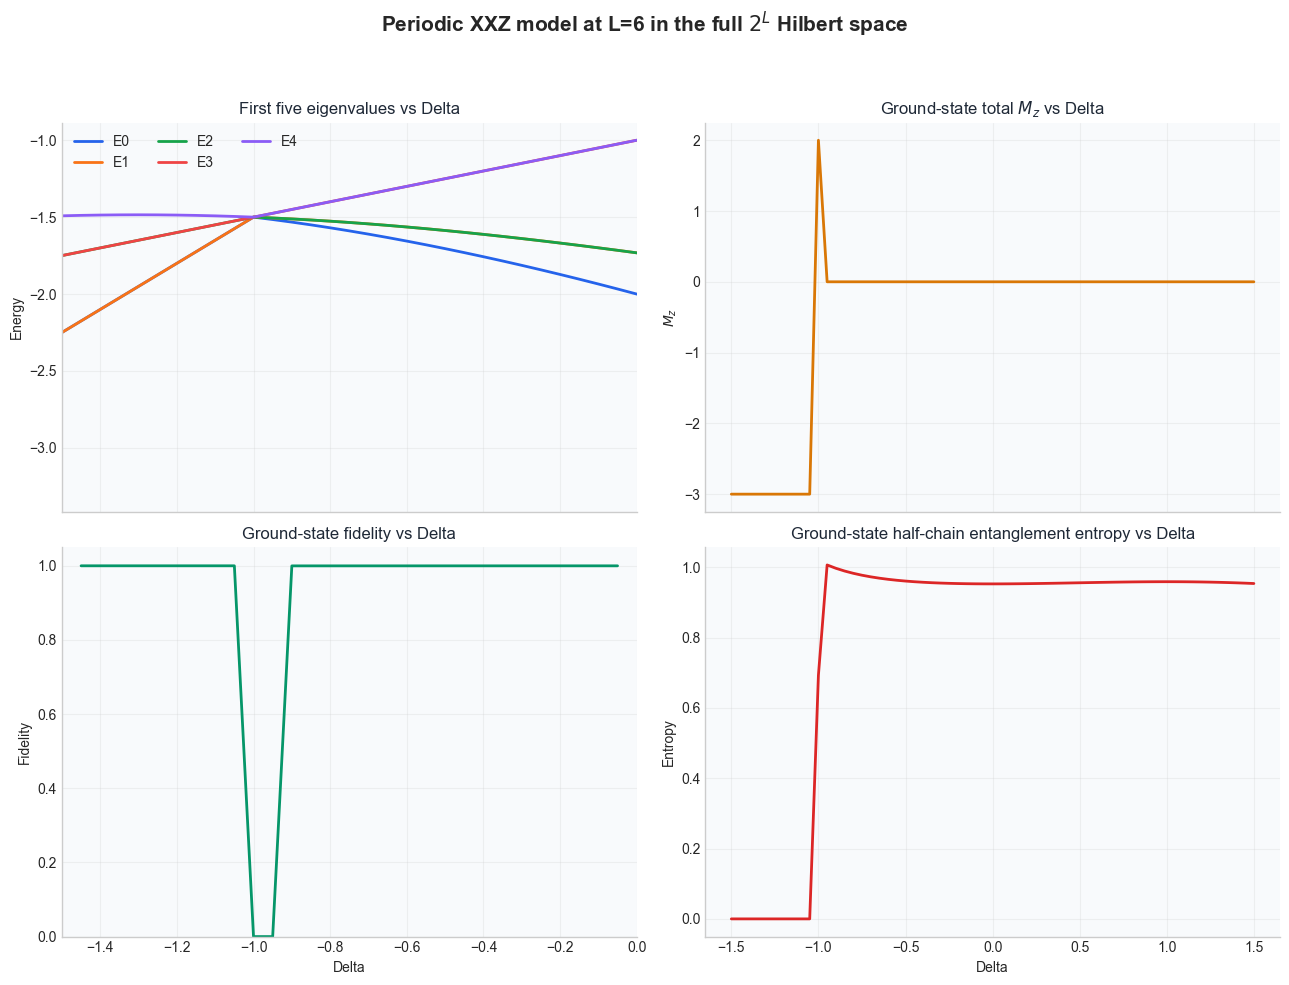

In [7]:
# Four-panel comparison plot versus Delta.
fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex='col')
fig.patch.set_facecolor('white')
panel_color = '#1f2937'
accent_energy = '#2563eb'
accent_mz = '#d97706'
accent_fidelity = '#059669'
accent_entropy = '#dc2626'
level_colors = ['#2563eb', '#f97316', '#16a34a', '#ef4444', '#8b5cf6']


for level in range(5):
    axes[0, 0].plot(delta_values, energy_levels[:, level], label=f'E{level}', linewidth=2, color=level_colors[level])
axes[0, 0].set_title('First five eigenvalues vs Delta', color=panel_color)
axes[0, 0].set_ylabel('Energy')
axes[0, 0].legend(ncol=3, frameon=False)
axes[0, 0].grid(True, alpha=0.25)
axes[0, 0].set_facecolor('#f8fafc')

axes[0, 1].plot(delta_values, mz_values, color=accent_mz, linewidth=2)
axes[0, 1].set_title('Ground-state total $M_z$ vs Delta', color=panel_color)
axes[0, 1].set_ylabel('$M_z$')
axes[0, 1].grid(True, alpha=0.25)
axes[0, 1].set_facecolor('#f8fafc')

axes[1, 0].plot(delta_fidelity, fidelity_values, color=accent_fidelity, linewidth=2)
axes[1, 0].set_title('Ground-state fidelity vs Delta', color=panel_color)
axes[1, 0].set_xlabel('Delta')
axes[1, 0].set_ylabel('Fidelity')
axes[1, 0].set_xlim(-1.5, 0.0)
axes[1, 0].set_ylim(0.0, 1.05)
axes[1, 0].grid(True, alpha=0.25)
axes[1, 0].set_facecolor('#f8fafc')

axes[1, 1].plot(delta_values, entropy_values, color=accent_entropy, linewidth=2)
axes[1, 1].set_title('Ground-state half-chain entanglement entropy vs Delta', color=panel_color)
axes[1, 1].set_xlabel('Delta')
axes[1, 1].set_ylabel('Entropy')
axes[1, 1].grid(True, alpha=0.25)
axes[1, 1].set_facecolor('#f8fafc')

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=10)

fig.suptitle(f'Periodic XXZ model at L={L} in the full $2^L$ Hilbert space', fontsize=15, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [8]:
# 3D comparison panel over Delta and J2z.
# The energy panel shows the first five eigenvalue surfaces.
# Fidelity is the ground-state overlap between neighboring Delta points for each J2z slice.
from IPython.display import HTML, display
import plotly.graph_objects as go
from plotly.subplots import make_subplots

class FullXXZChainJ2:
    """Periodic XXZ chain in the full 2^L Hilbert space with a next-nearest Ising term."""

    def __init__(self, L, Jxy=1.0, Delta=0.0, J2z=0.0, periodic=True):
        self.L = int(L)
        self.Jxy = float(Jxy)
        self.Delta = float(Delta)
        self.J2z = float(J2z)
        self.periodic = bool(periodic)
        self.dim = 1 << self.L
        self.states = np.arange(self.dim, dtype=np.uint64)
        self.nn_pairs = self._pairs(distance=1)
        self.nnn_pairs = self._pairs(distance=2)
        self.mz_values = np.array([int(state).bit_count() - self.L / 2 for state in self.states], dtype=float)

    def _pairs(self, distance):
        if self.periodic:
            return [(i, (i + distance) % self.L) for i in range(self.L)]
        return [(i, i + distance) for i in range(self.L - distance)]

    def build_hamiltonian(self):
        hamiltonian = np.zeros((self.dim, self.dim), dtype=float)
        one = np.uint64(1)
        for i, state in enumerate(self.states):
            diagonal = 0.0
            for left, right in self.nn_pairs:
                bit_left = np.uint64(self.L - 1 - left)
                bit_right = np.uint64(self.L - 1 - right)
                occ_left = (state >> bit_left) & one
                occ_right = (state >> bit_right) & one
                if occ_left == occ_right:
                    diagonal += self.Delta / 4.0
                else:
                    diagonal -= self.Delta / 4.0
                    if self.Jxy != 0.0:
                        flipped = state ^ ((one << bit_left) | (one << bit_right))
                        hamiltonian[i, int(flipped)] += self.Jxy / 2.0
            for left, right in self.nnn_pairs:
                bit_left = np.uint64(self.L - 1 - left)
                bit_right = np.uint64(self.L - 1 - right)
                occ_left = (state >> bit_left) & one
                occ_right = (state >> bit_right) & one
                if occ_left == occ_right:
                    diagonal += self.J2z / 4.0
                else:
                    diagonal -= self.J2z / 4.0
            hamiltonian[i, i] += diagonal
        return hamiltonian

    def diagonalize(self):
        hamiltonian = self.build_hamiltonian()
        eigvals, eigvecs = np.linalg.eigh(hamiltonian)
        return eigvals, eigvecs

    def magnetization(self, state):
        probabilities = np.abs(state) ** 2
        return float(np.dot(probabilities, self.mz_values))

    def half_chain_entropy(self, state):
        ell = self.L // 2
        psi_matrix = state.reshape((1 << ell, 1 << (self.L - ell)))
        singular_values = np.linalg.svd(psi_matrix, compute_uv=False)
        probabilities = singular_values ** 2
        probabilities = probabilities[probabilities > 1e-14]
        return float(-np.sum(probabilities * np.log(probabilities)))


delta_values_3d = np.linspace(-1.5, 1.5, 200)
j2z_values = np.linspace(-1.5, 1.5, 200)
energy_surfaces = [np.zeros((len(j2z_values), len(delta_values_3d)), dtype=float) for _ in range(5)]
mz_surface = np.zeros((len(j2z_values), len(delta_values_3d)), dtype=float)
entropy_surface = np.zeros((len(j2z_values), len(delta_values_3d)), dtype=float)
fidelity_surface = np.full((len(j2z_values), len(delta_values_3d)), np.nan, dtype=float)

for row, j2z in enumerate(j2z_values):
    chain_3d = FullXXZChainJ2(L=6, Jxy=1.0, Delta=delta_values_3d[0], J2z=float(j2z), periodic=True)
    previous_ground_state = None
    for col, delta in enumerate(delta_values_3d):
        chain_3d.Delta = float(delta)
        eigvals, eigvecs = chain_3d.diagonalize()
        for level in range(5):
            energy_surfaces[level][row, col] = eigvals[level]
        ground_state = eigvecs[:, 0]
        mz_surface[row, col] = chain_3d.magnetization(ground_state)
        entropy_surface[row, col] = chain_3d.half_chain_entropy(ground_state)
        if previous_ground_state is not None:
            fidelity_surface[row, col] = fidelity(previous_ground_state, ground_state)
        previous_ground_state = ground_state

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'type': 'surface'}, {'type': 'surface'}], [{'type': 'surface'}, {'type': 'surface'}]],
    subplot_titles=(
        'First five eigenvalues vs Delta and J2z',
        'Ground-state total Mz vs Delta and J2z',
        'Ground-state fidelity vs Delta and J2z',
        'Ground-state half-chain entanglement entropy vs Delta and J2z',
    ),
    vertical_spacing=0.08,
    horizontal_spacing=0.06,
)

surface_kwargs = dict(opacity=0.9, showscale=False)
energy_colors = ['#2563eb', '#f97316', '#16a34a', '#ef4444', '#8b5cf6']
for level in range(5):
    fig.add_trace(
        go.Surface(x=delta_values_3d, y=j2z_values, z=energy_surfaces[level], colorscale=[[0, energy_colors[level]], [1, energy_colors[level]]], opacity=0.55, showscale=False, name=f'E{level}'),
        row=1, col=1,
    )

fig.add_trace(
    go.Surface(x=delta_values_3d, y=j2z_values, z=mz_surface, colorscale='Oranges', **surface_kwargs),
    row=1, col=2,
)
fig.add_trace(
    go.Surface(x=delta_values_3d, y=j2z_values, z=fidelity_surface, colorscale='Greens', **surface_kwargs),
    row=2, col=1,
)
fig.add_trace(
    go.Surface(x=delta_values_3d, y=j2z_values, z=entropy_surface, colorscale='Reds', **surface_kwargs),
    row=2, col=2,
)

fig.update_layout(
    title=f'Periodic XXZ model at L=6 over Delta and J2z',
    height=1000,
    width=1300,
    margin=dict(l=10, r=10, t=60, b=10),
)

for scene_name in ['scene', 'scene2', 'scene3', 'scene4']:
    fig.layout[scene_name].xaxis.title = 'Delta'
    fig.layout[scene_name].yaxis.title = 'J2z'
    fig.layout[scene_name].zaxis.title = 'Value'

display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))